# Principal component analysis

Principal component analysis is a dimension reduction technique. It is used to reduce the number of dimensions (features) in a dataset. This is very useful for figuring out the features that best contribute to the variance in the dataset, but "principal components" can be difficult to understand. How can 2 different features be combined to form a new feature? What does that feature mean?

In this lab, you will calculate the principal component of a 2-dimensional dataset. First we will do it on a small dataset so that you can see the rotations of the features and how 2-D data is turned into 1-D data. Then you will use existing functions to calculate the principal components.

### Maths Resources
- This [StatQuest video on principal component analysis](https://www.youtube.com/watch?v=FgakZw6K1QQ) clearly explains the steps for implementing principal component analysis.

- This [3 Blue 1 Brown video on Eigenvectors](https://www.youtube.com/watch?v=PFDu9oVAE-g) explains how eigenvectors are actually a form of rotation.

## A small synthetic dataset

We will start by using the same, small, synthetic dataset that we used in the "Clustering" lab. Notice that we declare two sets of features: X1 and X2. X1 gets plotted on the X-axis, but X2 goes on the vertical axis (the "y-axis"). We won't call it the y-axis because we usually save "y" for labels rather than features in this module.

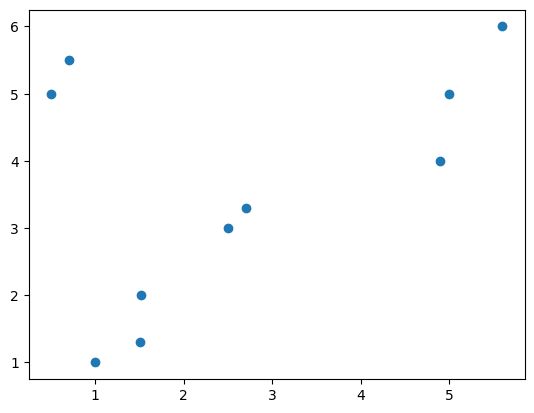

In [3]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# generate some reandom points (manually)
X1 = np.array([0.5,0.7, 1,1.5,1.52,2.5,2.7, 4.9,5,5.6])
X2 = np.array([5,5.5,1,1.3,2,3,3.3,4,5,6])
# plot the data
plt.plot(X1,X2,'o')

The first step in calculating the principal components is to shift the dataset so that it effectively has "zero mean". That means that we calculate the mean of all the points, and then subtract the mean off of all the points. We can take each dimension independently. The cells below show this.

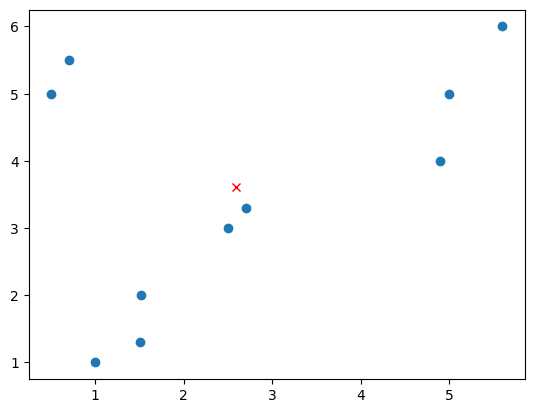

In [4]:
## Calculating the mean
mean_X1 = np.mean(X1)
mean_X2 = np.mean(X2)
plt.plot(X1,X2,'o')
plt.plot(mean_X1, mean_X2, 'x', color="red")
plt.show()

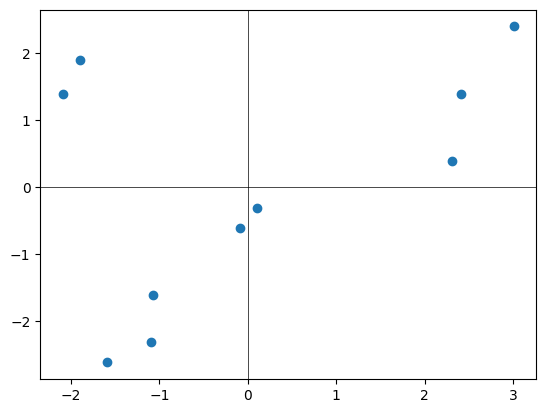

In [ ]:
# Now shift the graph so that the data points have "zero mean"
X1_shifted = X1 - mean_X1
X2_shifted = X2 - mean_X2
plt.plot(X1_shifted,X2_shifted,'o')
# add the axes so we can see where the (0,0) origin is.
plt.axhline(0, color='black', linewidth=.5)
plt.axvline(0, color='black', linewidth=.5)
plt.show()

Our next step is to plot a "best fit" line. Luckily numpy has a function that can calculate this when given 2 arrays of data. The only thing you need to do is transform the first array slightly.

The line is expressed as a gradient and a cut on the y-axis.

C:\Users\PJ8227\AppData\Local\Temp\ipykernel_23288\1142892285.py:3: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, c = np.linalg.lstsq(A, X2_shifted)[0]


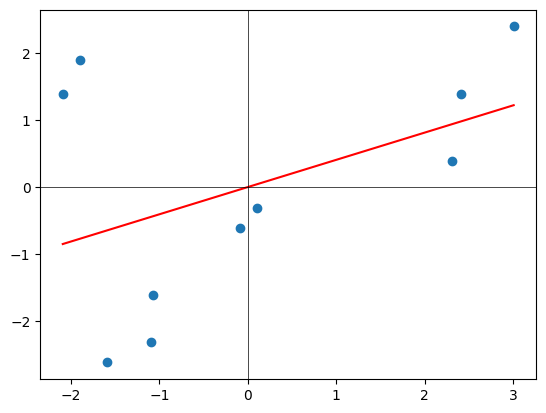

In [11]:
# Use least squares to plot the best fit line: Follow documentation at https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html
A = np.vstack([X1_shifted, np.ones(len(X1_shifted))]).T
m, c = np.linalg.lstsq(A, X2_shifted)[0]

plt.plot(X1_shifted,X2_shifted,'o')
plt.plot(X1_shifted, m*X1_shifted + c, 'r', label='Fitted line')
# add the axes
plt.axhline(0, color='black', linewidth=.5)
plt.axvline(0, color='black', linewidth=.5)
plt.show()

In [16]:
print("Our PC1 has a slope of {} and cut of {}".format(m, c))

Our PC1 has a slope of 0.4051019567755594 and cut of -4.2130001622920406e-16


What this means, is that for every step along the X1 axis, we take only 0.4 steps up the X2 axis. Our principal component would be 5 parts X1 to 2 parts X2. What that means is that feature X1 is 2.5 times more important than feature X2.
Notice that c is very small (i.e. it is zero).

Because we are only working in 2-dimensions, PC2 is simply a perpendicular line to PC1. It's slope will be 1/m and we can plot it like this:

Slopes multiplied give -1.0


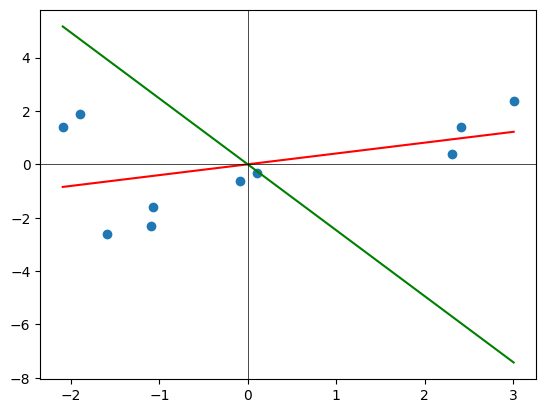

In [21]:
PC1_m = m
PC2_m = (-1/m)

print("Slopes multiplied give {}".format(PC1_m*PC2_m))

plt.plot(X1_shifted,X2_shifted,'o')
plt.plot(X1_shifted, PC1_m*X1_shifted + c, 'red', label='PC1')
plt.plot(X1_shifted, PC2_m*X1_shifted + c, 'green', label='PC2')
# add the axes
plt.axhline(0, color='black', linewidth=.5)
plt.axvline(0, color='black', linewidth=.5)
plt.show()

## Using existing functions

You will learn how to fit PCA on a dataset and reduce its dimension, visualise
eigenvectors and eigenfaces. Finally, you will be asked to compare classification performance of
two different classifiers (Support Vector Machine and Random Forests) on original datasets versus
their performances on dimensionally-reduced datasets.
For more resources and in-depth mathematical / technical discussion of PCA, you can refer to the
following resources:

- [Materials in this lab are adapted from the Data Science Book](https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html)

- [Good example using hand-written digits Github](https://github.com/mGalarnyk/Python_Tutorials/blob/master/Sklearn/PCA/PCA_Image_Reconstruction_and_such.ipynb)


### 1.1 Demonstration
Let us first generate some more data (2 dimensional, bigger than the above), and illustrate how we can use sklearn to compute
the PCA’s, plot it and perform simple tasks:

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

In [24]:
# generate some data
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 500)).T

(-3.019042068766703, 3.271550829363233, -1.029312447435016, 1.302811531441772)

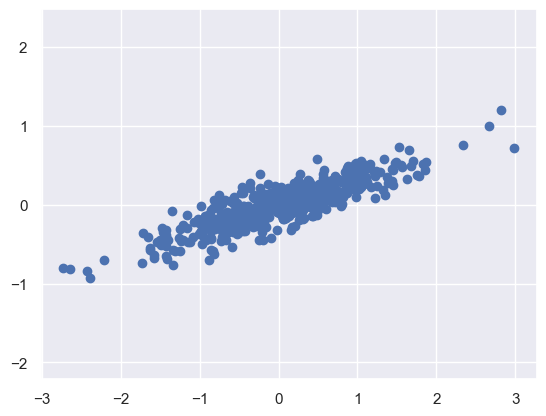

In [25]:
# plot data
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal')

In [26]:
# lets apply PCA using sklearn
from sklearn.decomposition import PCA
# create a PCA instance with two components
pca = PCA(n_components=2)
# fit it to the data
pca.fit(X)

PCA(n_components=2)

One thing to note that the number of principal components is set to equal the number of features
in your dataset. You can check this as follows:

In [27]:
print(f'There are {len(pca.components_)} Principal Components')

There are 2 Principal Components


Recall from the lecture, that we are interested in keeping the principal components with the highest
variance. Here is how we can check the variance of these components, you will note that the
first component has significantly higher variance than the second. This can also be seen from the
plot below (longer line corresponds to the principal component with the highest variance)

In [28]:
print(pca.explained_variance_)

[0.750087  0.0197852]


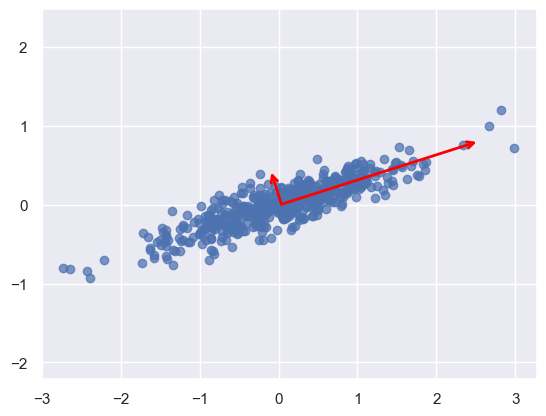

In [31]:
def draw_vector(v0, v1, ax=None):
        ax = plt.gca()
        arrowprops=dict(arrowstyle='->',
        linewidth=2,
        color="red",
        shrinkA=0, shrinkB=0)
        ax.annotate('', v1, v0, arrowprops=arrowprops)
# plot data
plt.scatter(X[:, 0], X[:, 1], alpha=0.72)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

## Faces Example

Recall that in Week 4, we used a "Face Recognition Example". The dataset used is a collection of face
images for public figures. Each image in the dataset is 62 x 47 pixels. In computer vision, such
image will be presented as a one feature vector, you can think of this as a row of 2914 pixels for
each images. In other words, each image is represented by 2194 features. Lets see how can we use
PCA to reduce this large number of features:

In [32]:
from sklearn.datasets import fetch_lfw_people
# load faces dataset
faces = fetch_lfw_people(min_faces_per_person=60)
# check labels and the shape of the data
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Fitting PCA is straightforward, and the key thing is to decide the number of components you
want to keep. Below, we fit PCA to the facial data, and stating that we want to keep the highest
200 principal components (highest in variance)

In [33]:
from sklearn.decomposition import PCA as RandomizedPCA
pca = RandomizedPCA(200)
pca.fit(faces.data)

PCA(n_components=200)

**Eigenfaces**: Let's visualise the images associated with the first principal components (highest in
terms of variance). Because we are plotting these principal components (commonly known as
eigenvectors), such images are called eigenfaces.

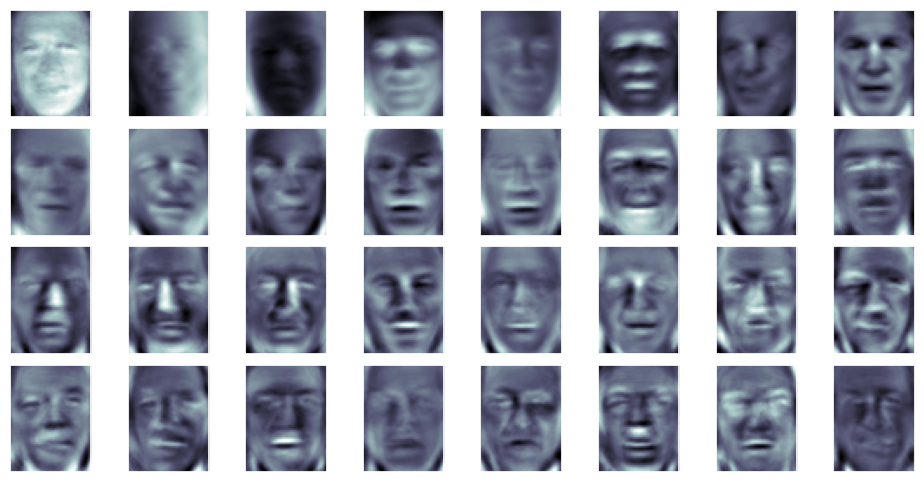

In [34]:
# lets visualise these com
fig, axes = plt.subplots(4, 8, figsize=(12, 6),
    subplot_kw={'xticks':[], 'yticks':[]},
    gridspec_kw=dict(hspace=0.1, wspace=0.1))
# notice pca.components is a numpy array
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(62, 47), cmap='bone')


Notice that the first few eigenfaces from the top left are associated with the angle of lightening
on the face, these are pca.components_[1], pca.components_[2], . . . while later principal
components are more associated with certain facial features such as nose, eyes and mouth

We can explore the cumulative variance of the principal components above to see how much
facial data is preserved. Recall, when computing the principal components, we want to keep
the most important features, and get rid of redundant information.

Text(0, 0.5, 'cumulative explained variance')

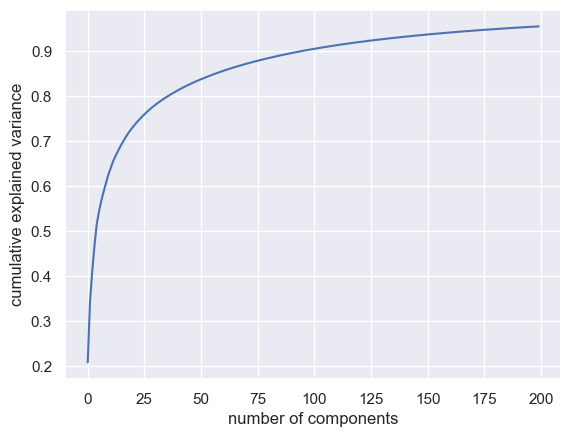

In [35]:
# plot cumulative variance captured by pca
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

You can see from the above figure, that the 200 components captures more than almost 98%
of the original data

You can verify this further by reconstructing the facial images using these 200 components,
and compare the reconstructed images with the original ones from the dataset. The code
below illustrates this:

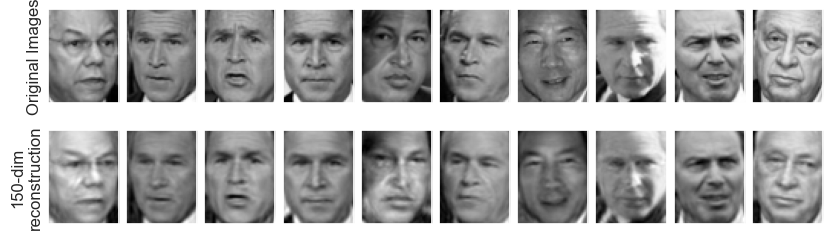

In [37]:
# compute projected faces
components = pca.transform(faces.data)
projected = pca.inverse_transform(components)
# plot results
# Plot the results
fig, ax = plt.subplots(2, 10, figsize=(10, 3.),
subplot_kw={'xticks':[], 'yticks':[]},
gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    # plot original faces
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    # plot reconstructed faces from pca
    ax[1, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')
    ax[0, 0].set_ylabel('Original Images')
    ax[1, 0].set_ylabel('150-dim\nreconstruction')

Notice that the second row of images in the figure above shows the reconstructed faces from
principal components. In other words, instead of almost 3000 initial features, these were
reconstructed from only 200.

Consider the different images reconstructions below. We used different numbers of components,
and as you can see there is clear relation between the number of components used
and the "quality" of the reconstructed images. Some of these principal components clearly represent wrinkles.

In [38]:
# Fit PCA and keep the top 150 eigenvectors
# Compute the components and projected faces
pca = RandomizedPCA(150).fit(faces.data)
components = pca.transform(faces.data)
projected = pca.inverse_transform(components)
# only keep top 100 eigenvectors
pca0 = RandomizedPCA(100).fit(faces.data)
components0 = pca0.transform(faces.data)
projected0 = pca0.inverse_transform(components0)
# same as above but keep only 50 eigenvectors
pca1 = RandomizedPCA(50).fit(faces.data)
components1 = pca1.transform(faces.data)
projected1 = pca1.inverse_transform(components1)

Text(0, 0.5, '50-dim')

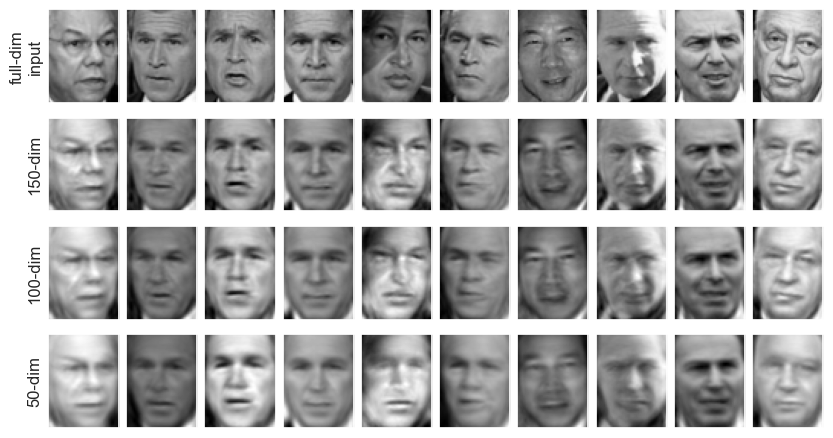

In [39]:
# Plot the results
fig, ax = plt.subplots(4, 10, figsize=(10, 5.5),
subplot_kw={'xticks':[], 'yticks':[]},
gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    ax[1, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')
    ax[2, i].imshow(projected0[i].reshape(62, 47), cmap='binary_r')
    ax[3, i].imshow(projected1[i].reshape(62, 47), cmap='binary_r')
ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('150-dim')
ax[2, 0].set_ylabel('100-dim')
ax[3, 0].set_ylabel('50-dim')

### Exercise 1
Recall that in week 4 we used the same dataset of facial images, and applied Support Vector Machine
to classify images after reducing the dimension of the dataset to 150 principal components.
To assess how significant the impact of dimension reduction to the performance of a classifier, in
this task you will do the following:

- Experiment 1: Build and evaluate an SVM model to classify face images without applying
dimension reduction (e.g. don’t use PCA), instead use all the features in the dataset

- Experiment 2: Apply PCA and keep the first 200 principal components, then using SVM to
build a classifier using the reduced dataset

- Compare results obtained from week 4 with results of experiment 1 and experiment 2. Do
you see significant different in accuracy?

## Hand-Written Digits
MNIST dataset is very popular in the Machine Learning community. It is considered as the ‘hello
world’ example in programming (for image processing). The dataset contains images of hand-written digits, and the task
is to build a classifier that classifies these images. Let's first load the dataset and do quick data exploration, then the tasks will be outlined
to you:

In [40]:
from sklearn.datasets import load_digits
from sklearn.datasets import fetch_openml
# load the dataset
mnist_data = fetch_openml('mnist_784', version=1)

In [41]:
# check data dimension
print('MNIST Dimension: ',mnist_data['data'].shape[0], ' Rows')
print('MNIST Dimension: ',mnist_data['data'].shape[1], ' Features/ Columns')

MNIST Dimension:  70000  Rows
MNIST Dimension:  784  Features/ Columns


In [52]:
# split the data into features and labels
X, y = mnist_data['data'], mnist_data['target']
# check the shapes of the data
print('Shape of X:', X.shape, '\n', 'Shape of y:', y.shape)
display(X)

Shape of X: (70000, 784) 
 Shape of y: (70000,)


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


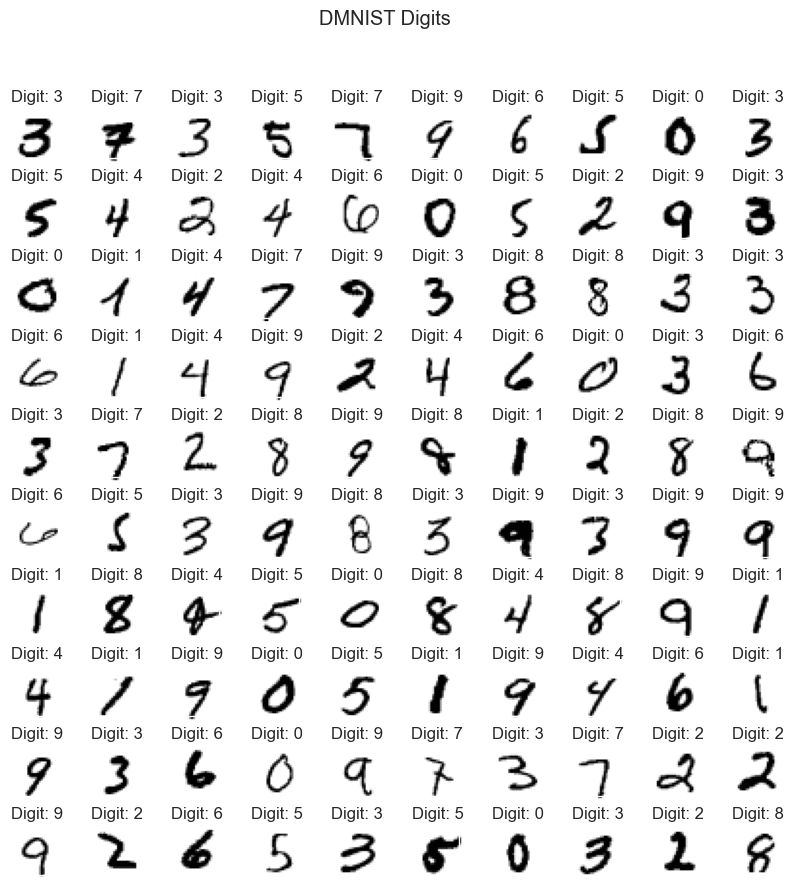

In [61]:
# The function below adapted from kaggle and is used to display some of the digits
# source https://www.kaggle.com/gainknowledge/mnist-scikit-learn-tutorial
n = 10
m = 10
# list to store image indices
images = []
#print(X.shape)
#print(X.loc[50630].to_numpy())

def displayData(X,Y,n,m):
    fig, ax = plt.subplots(nrows=n, ncols=m, figsize=(10,10))
    fig.suptitle( "DMNIST Digits")
    # loop over randomly drawn numbers
    for i in range(n):
        for j in range(m):
            ind = np.random.randint(X.shape[0])
            images.append(ind)
            tmp = X.loc[ind].to_numpy()
            tmp = tmp.reshape(28,28)
            ax[i,j].set_title("Digit: {}".format(Y[ind]))
            ax[i,j].imshow(tmp, cmap='gray_r') # display it as gray colors.
            plt.setp(ax[i,j].get_xticklabels(), visible=False)
            plt.setp(ax[i,j].get_yticklabels(), visible=False)
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

# call the function
displayData(X,y,n,m)


### Exercise 2
In this exercise, you will perform the following tasks across two separate experiments and then
compare the results:

#### Experiment 1:
- Split the data into training and testing sets (70% of the data for training)

- Create and train random forest classifier and report the results (accuracy)

#### Experiment 2:
- Apply PCA to the MNIST dataset

- Keep the n principal components that capture 95% or more of the data

- Fit Random forest on the reduced dataset and compare results with those in Experiment 1
Hint: You might want to plot the cumulative variance captured by PCA to see how many components
n you want to keep
